In [101]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

In [102]:
import os

output_dir = os.path.expanduser('~/Desktop/nigeria_charts')
os.makedirs(output_dir, exist_ok=True)
print(f"Charts will save to: {output_dir}")

Charts will save to: /Users/apple/Desktop/nigeria_charts


In [103]:
!pip install openpyxl

In [104]:
df = pd.read_excel('Nigeria_Power_Supplementary_Dataset.xlsx')

In [105]:
all_sheets_main = pd.read_excel('Nigeria_Power_Grid_Dataset.xlsx', sheet_name=None)

df_collapses = all_sheets_main['Grid_Collapses']
df_generation = all_sheets_main['Generation_Capacity']
df_disco = all_sheets_main['DisCo_Performance']
df_grid = all_sheets_main['Grid_Quality_Monthly']

In [106]:
for name, df in all_sheets_main.items():
    print(f'{name}: {df.isnull().sum().sum()} nulls | shape: {df.shape}')

Grid_Collapses: 94 nulls | shape: (18, 10)
Generation_Capacity: 46 nulls | shape: (11, 8)
DisCo_Performance: 54 nulls | shape: (15, 9)
Grid_Quality_Monthly: 61 nulls | shape: (15, 10)
Data_Dictionary: 28 nulls | shape: (21, 5)


In [107]:
all_sheets = pd.read_excel('Nigeria_Power_Supplementary_Dataset.xlsx', sheet_name=None)

In [108]:
df_economic   = all_sheets['Economic_Cost_Outages']
df_regional   = all_sheets['Africa_Regional_Comparison']
df_population = all_sheets['Population_Access_Data']
df_generator  = all_sheets['Generator_Shadow_Economy']
df_dict       = all_sheets['Data_Dictionary']

In [109]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column                                       Non-Null Count  Dtype
---  ------                                       --------------  -----
 0   Nigeria Power Grid Crisis — Data Dictionary  17 non-null     str  
 1   Unnamed: 1                                   15 non-null     str  
 2   Unnamed: 2                                   15 non-null     str  
 3   Unnamed: 3                                   15 non-null     str  
 4   Unnamed: 4                                   15 non-null     str  
dtypes: str(5)
memory usage: 3.0 KB


,Nigeria Power Grid Crisis — Data Dictionary,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,17,15,15,15,15
unique,7,15,15,6,12
top,Generation_Capacity,Column / Field,Definition,%,Calculated
freq,5,1,1,5,3


In [110]:
df.isnull().sum()

Nigeria Power Grid Crisis — Data Dictionary    4
Unnamed: 1                                     6
Unnamed: 2                                     6
Unnamed: 3                                     6
Unnamed: 4                                     6
dtype: int64

In [111]:
df_raw = all_sheets['Economic_Cost_Outages']

In [112]:
df_economic = df_raw.iloc[:6].copy()
df_economic['Year'] = df_economic['Year'].astype(int)

In [113]:
df_economic['Loss as % of GDP'] = (df_economic['Economic Loss — Grid Outages (USD bn)'] / df_economic['GDP (USD bn)'] * 100).round(2)

In [114]:
df_economic['Total Energy Crisis Cost (USD bn)'] = (df_economic['Economic Loss — Grid Outages (USD bn)'] + df_economic['Generator Fuel Spend (USD bn)']).round(2)

In [115]:
df_sectors = df_raw.iloc[10:18, :3].copy()
df_sectors.columns = ['Sector', 'Annual Loss (USD bn)', 'Key Impact']
df_sectors = df_sectors.reset_index(drop=True)

In [116]:
df.isnull().sum()

Nigeria Power Grid Crisis — Data Dictionary    4
Unnamed: 1                                     6
Unnamed: 2                                     6
Unnamed: 3                                     6
Unnamed: 4                                     6
dtype: int64

In [117]:
df_raw_econ = all_sheets['Economic_Cost_Outages']
df_economic = df_raw_econ.iloc[:6].copy().reset_index(drop=True)
df_economic['Year'] = df_economic['Year'].astype(int)
for col in ['GDP (USD bn)', 'Economic Loss — Grid Outages (USD bn)']:
    df_economic[col] = pd.to_numeric(df_economic[col], errors='coerce')
df_economic['Loss as % of GDP'] = (df_economic['Economic Loss — Grid Outages (USD bn)'] / df_economic['GDP (USD bn)'] * 100).round(2)
df_economic['Total Energy Crisis Cost (USD bn)'] = (df_economic['Economic Loss — Grid Outages (USD bn)'] + df_economic['Generator Fuel Spend (USD bn)']).round(2)
df_economic = df_economic.drop(columns=['Notes / Source'])

df_sectors = df_raw_econ.iloc[10:18, :3].copy().reset_index(drop=True)
df_sectors.columns = ['Sector', 'Annual Loss (USD bn)', 'Key Impact']
df_sectors['Annual Loss (USD bn)'] = pd.to_numeric(df_sectors['Annual Loss (USD bn)'], errors='coerce')

In [118]:
df_raw_reg = all_sheets['Africa_Regional_Comparison']
df_regional = df_raw_reg.iloc[:9].copy().reset_index(drop=True)
for col in ['Population (mn) 2024', 'GDP (USD bn) 2024', 'Installed Capacity (GW)',
            'Actual/Available Generation (GW)', 'Electricity Access (% pop)']:
    df_regional[col] = pd.to_numeric(df_regional[col], errors='coerce')
df_regional = df_regional.drop(columns=['Notes'])

df_benchmarks = df_raw_reg.iloc[14:22, :6].copy().reset_index(drop=True)
df_benchmarks.columns = ['Metric', 'Nigeria', 'South Africa', 'Ghana', 'Kenya', 'Global Best Practice']


In [119]:
df_raw_gen = all_sheets['Generator_Shadow_Economy']
df_generator = df_raw_gen.iloc[:6].copy().reset_index(drop=True)
for col in ['Year', 'No. of Generators in Nigeria (mn)', 'Grid Capacity (GW)', 'Private Generator Capacity (GW)']:
    df_generator[col] = pd.to_numeric(df_generator[col], errors='coerce')
df_generator['Year'] = df_generator['Year'].astype(int)
df_generator['Generator/Grid Capacity Ratio'] = (df_generator['Private Generator Capacity (GW)'] / df_generator['Grid Capacity (GW)']).round(2)
df_generator = df_generator.drop(columns=['Notes'])

df_gen_facts = df_raw_gen.iloc[9:19, :4].copy().reset_index(drop=True)
df_gen_facts.columns = ['Metric', 'Value', 'Context', 'Source']


In [120]:
df_raw_pop = all_sheets['Population_Access_Data']
df_population = df_raw_pop.iloc[:20].copy().reset_index(drop=True)
df_population['People Without Power (mn)'] = (
    df_population['Population (mn) 2024 est.'] * (1 - df_population['Est. Access Rate (%)'] / 100)
).round(2)
df_population = df_population.drop(columns=['Notes'])

In [121]:
for name, df_ in [('df_economic', df_economic), ('df_sectors', df_sectors),
                  ('df_regional', df_regional), ('df_benchmarks', df_benchmarks),
                  ('df_generator', df_generator), ('df_gen_facts', df_gen_facts),
                  ('df_population', df_population)]:
    total = df_.isnull().sum().sum()
    print(f'{name}: {total} nulls')

df_economic: 0 nulls
df_sectors: 0 nulls
df_regional: 0 nulls
df_benchmarks: 0 nulls
df_generator: 0 nulls
df_gen_facts: 0 nulls
df_population: 0 nulls


In [122]:
df_economic.describe()

,Year,GDP (USD bn),Economic Loss — Grid Outages (USD bn),Loss as % of GDP,Generator Fuel Spend (USD bn),Total Energy Crisis Cost (USD bn),Firms Reporting Sales Loss (%),Avg Annual Outage Hours per Firm
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.0,6.000000
mean,2021.500000,444.666667,25.416667,5.776667,17.250000,42.666667,13.0,2475.000000
std,1.870829,48.557251,0.801041,0.715029,4.021816,4.665476,0.0,412.007281
min,2019.000000,362.800000,24.000000,5.130000,13.500000,37.500000,13.0,2100.000000
25%,2020.250000,434.425000,25.125000,5.475000,14.000000,39.125000,13.0,2212.500000
50%,2021.500000,444.450000,25.750000,5.565000,16.000000,41.750000,13.0,2275.000000
75%,2022.750000,470.075000,26.000000,5.730000,21.000000,47.000000,13.0,2825.000000
max,2024.000000,506.600000,26.000000,7.170000,22.000000,48.000000,13.0,3000.000000


In [123]:
df_sectors.describe()

,Annual Loss (USD bn)
count,8.000000
mean,5.562500
std,4.607738
min,0.900000
25%,1.650000
50%,4.300000
75%,10.000000
max,12.000000


In [124]:
df_regional.describe()

,Population (mn) 2024,GDP (USD bn) 2024,Installed Capacity (GW),Actual/Available Generation (GW),Electricity Access (% pop),Per Capita Consumption (kWh/yr),Grid Reliability (avg outage hrs/month),ATC&C / Distribution Loss (%),No. of People Without Power (mn)
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,80.111111,179.922222,18.511111,10.888889,68.077778,804.111111,51.222222,22.000000,27.377778
std,63.559902,140.098338,26.106917,15.843251,20.210998,1308.996223,76.468585,11.905881,31.852581
min,18.000000,31.000000,1.400000,0.800000,38.000000,90.000000,4.000000,9.000000,1.100000
25%,34.000000,76.400000,2.300000,1.800000,53.000000,169.000000,18.000000,18.000000,5.900000
50%,62.000000,118.100000,5.500000,3.800000,70.000000,250.000000,22.000000,20.000000,9.900000
75%,107.000000,347.000000,13.600000,5.800000,84.400000,380.000000,45.000000,24.000000,41.500000
max,220.000000,373.000000,65.900000,42.000000,99.000000,3986.000000,250.000000,50.000000,86.600000


## Observation
The median is 4.3bn Naira but the mean is 5.6bn Naira, meaning a few large sectors are pulling the average up (skewed distribution)
The top 25% of sectors each lose more than 10bn Naira, so 2 sectors dominate the total loss

In [125]:
df_sectors.sort_values('Annual Loss (USD bn)', ascending=False).reset_index(drop=True) 

,Sector,Annual Loss (USD bn),Key Impact
0,Generator Fuel (households),12.0,$12bn/yr: 22 million households & small busine...
1,SMEs / Informal Economy,10.0,"Lost sales, spoiled goods, shutdown of fridges..."
2,Generator Fuel (corporates),10.0,Businesses spend up to 40% of opex on power (CBN)
3,Manufacturing / Industry,6.5,Reduced TFP; 1% outage increase = 3.5% TFP loss
4,Telecoms (tower downtime),2.1,226M subscribers affected; BTS running on dies...
5,Agriculture / Cold Chain,1.8,Perishable food losses; irrigation pump failure
6,Healthcare,1.2,"Vaccine spoilage, surgery disruptions, ICU fai..."
7,Financial Services / Fintech,0.9,POS/ATM downtime; payment system failures duri...


In [126]:
df_generator.describe()

,Year,No. of Generators in Nigeria (mn),Grid Capacity (GW),Private Generator Capacity (GW),Generator/Grid Capacity Ratio,Total Annual Generator Spend (USD bn),Generator Fuel Spend (USD bn),Diesel Price (NGN/litre),% Businesses Using Generators
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.0
mean,2021.500000,20.333333,4.100000,39.000000,9.515000,17.583333,12.666667,491.666667,86.0
std,1.870829,1.632993,0.109545,2.828427,0.675448,4.176322,3.011091,347.817002,0.0
min,2019.000000,18.000000,3.900000,35.000000,8.540000,13.500000,10.000000,220.000000,86.0
25%,2020.250000,19.250000,4.100000,37.250000,9.082500,14.000000,10.000000,247.500000,86.0
50%,2021.500000,20.500000,4.100000,39.000000,9.635000,17.000000,12.000000,345.000000,86.0
75%,2022.750000,21.750000,4.175000,41.500000,10.000000,21.500000,15.500000,630.000000,86.0
max,2024.000000,22.000000,4.200000,42.000000,10.260000,22.000000,16.000000,1100.000000,86.0


The grid didn't move. The shadow economy did though, and diesel prices made it 5x more expensive

In [127]:
df_population.describe()

,Population (mn) 2024 est.,Est. Access Rate (%),People Without Power (mn),DisCo ATC&C Loss (%),Avg Daily Supply (hrs)
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,6.810000,39.400000,3.964500,56.280000,3.375000
std,3.477885,17.488041,1.952188,14.284205,1.738685
min,3.500000,15.000000,1.200000,31.800000,1.000000
25%,4.500000,24.250000,2.772500,42.700000,2.000000
50%,5.750000,37.500000,3.710000,55.300000,3.250000
75%,8.125000,51.250000,4.530000,65.400000,4.125000
max,16.000000,72.000000,9.750000,78.600000,8.000000


**Est. Access Rate (%)**: mean is 39.4%, but ranges from 15% to 72%. That's a massive spread across states. The average Nigerian state has less than 40% electricity access

**People Without Power (mn)**: mean 3.96 million per state, but max is 9.75 million. Some states have nearly 10 million people in the dark

**DisCo ATC&C Loss (%)**: mean 56%, min 31.8%, max 78.6%. Even the best DisCo loses nearly a third of electricity before it reaches customers. The worst loses almost 4 in every 5 units. That's the definition of a broken distribution system.

**Avg Daily Supply (hrs)**: mean 3.375 hours, min 1 hour, max 8 hours. The average Nigerian state gets 3.4 hours of electricity per day. The worst gets 1.

Where you live in Nigeria determines everything, from 8 hours of power a day in Lagos to 1 hour in Taraba

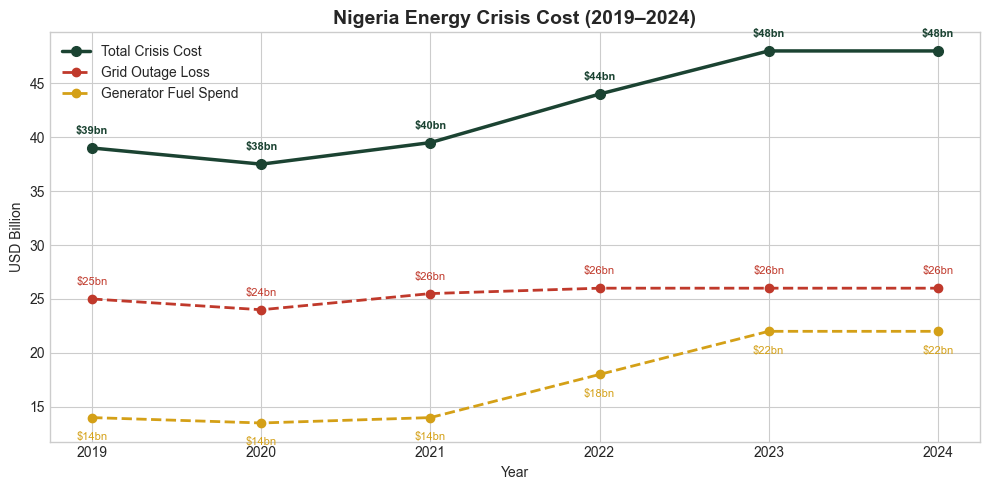

In [128]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_economic['Year'], df_economic['Total Energy Crisis Cost (USD bn)'],
        color='#1B4332', linewidth=2.5, marker='o', markersize=7, label='Total Crisis Cost')

ax.plot(df_economic['Year'], df_economic['Economic Loss — Grid Outages (USD bn)'],
        color='#C0392B', linewidth=2, marker='o', markersize=6, linestyle='--', label='Grid Outage Loss')

ax.plot(df_economic['Year'], df_economic['Generator Fuel Spend (USD bn)'],
        color='#D4A017', linewidth=2, marker='o', markersize=6, linestyle='--', label='Generator Fuel Spend')

# Add value labels
for i, row in df_economic.iterrows():
    ax.annotate(f"${row['Total Energy Crisis Cost (USD bn)']:.0f}bn",
                (row['Year'], row['Total Energy Crisis Cost (USD bn)']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8, color='#1B4332', fontweight='bold')
    
    ax.annotate(f"${row['Economic Loss — Grid Outages (USD bn)']:.0f}bn",
                (row['Year'], row['Economic Loss — Grid Outages (USD bn)']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8, color='#C0392B')
    
    ax.annotate(f"${row['Generator Fuel Spend (USD bn)']:.0f}bn",
                (row['Year'], row['Generator Fuel Spend (USD bn)']),
                textcoords='offset points', xytext=(0, -16), ha='center', fontsize=8, color='#D4A017')

ax.set_title('Nigeria Energy Crisis Cost (2019–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('USD Billion')
ax.legend()
plt.tight_layout()
plt.show()

The green line (Total Crisis Cost) is the sum of the red and gold lines.
Green line (Total Crisis Cost): The full economic burden. Peaked at USD 48bn in 2023–2024
USD 48bn a year that produces no infrastructure, no growth, no return, it just keeps businesses barely alive.
To put it in context, $48bn is larger than Nigeria's entire 2024 federal budget.

In [129]:
# Grid_Collapses
df_collapses = all_sheets_main['Grid_Collapses'].iloc[:6].copy().reset_index(drop=True)
df_collapses['Year'] = df_collapses['Year'].astype(int)
df_collapses['Total Incidents'] = df_collapses['Total Collapses'] + df_collapses['Partial Collapses']
df_collapses = df_collapses.drop(columns=['Notes'])

# separate sub-table
df_collapses_q4 = all_sheets_main['Grid_Collapses'].iloc[9:15, :5].copy().reset_index(drop=True)
df_collapses_q4.columns = ['Date', 'Type', 'Trigger / Cause', 'DisCos Affected', 'Est. Restoration Time']

# Generation_Capacity
df_generation = all_sheets_main['Generation_Capacity'].iloc[:7].copy().reset_index(drop=True)
df_generation['Year'] = df_generation['Year'].astype(int)
df_generation['Capacity Utilization (%)'] = (
    df_generation['Avg Actual Generation (MW)'] / df_generation['Installed Capacity (MW)'] * 100
).round(2)
df_generation['Gap to 30,000MW Target (MW)'] = 30000 - df_generation['Avg Actual Generation (MW)']
df_generation = df_generation.drop(columns=['Notes'])

# DisCo_Performance
df_disco = all_sheets_main['DisCo_Performance'].iloc[:11].copy().reset_index(drop=True)
df_disco['Payment Rate (%)'] = (
    df_disco['Revenue Collected (₦bn)'] / df_disco['NBET Invoice (₦bn)'] * 100
).round(2)
df_disco = df_disco.drop(columns=['Notes'])

# Grid_Quality_Monthly
df_grid = all_sheets_main['Grid_Quality_Monthly'].iloc[:12].copy().reset_index(drop=True)
df_grid['Freq Deviation (Hz)'] = (df_grid['Avg Frequency (Hz)'] - df_grid['Frequency Target (Hz)']).round(3)
df_grid['Voltage Deviation (kV)'] = (df_grid['Avg Voltage (kV)'] - df_grid['Voltage Target (kV)']).round(2)
df_grid = df_grid.drop(columns=['Notes'])

In [130]:
for name, df in [('df_collapses', df_collapses), ('df_collapses_q4', df_collapses_q4),
                 ('df_generation', df_generation), ('df_disco', df_disco), ('df_grid', df_grid)]:
    print(f'{name}: {df.isnull().sum().sum()} nulls | shape: {df.shape}')

df_collapses: 0 nulls | shape: (6, 9)
df_collapses_q4: 0 nulls | shape: (6, 5)
df_generation: 1 nulls | shape: (7, 7)
df_disco: 0 nulls | shape: (11, 8)
df_grid: 0 nulls | shape: (12, 9)


In [131]:
df_generation = df_generation.dropna(subset=['Total Generation (GWh)']).reset_index(drop=True)

In [132]:
df_generation.isnull().sum()

Year                           0
Installed Capacity (MW)        0
Available Capacity (MW)        0
Avg Actual Generation (MW)     0
Total Generation (GWh)         0
Capacity Utilization (%)       0
Gap to 30,000MW Target (MW)    0
dtype: int64

In [133]:
df_collapses.describe()

,Year,Q2 Incidents,Q3 Incidents,Q4 Incidents
count,6.000000,6.000000,6.000000,6.000000
mean,2021.500000,1.666667,2.666667,3.166667
std,1.870829,0.816497,0.816497,0.983192
min,2019.000000,1.000000,2.000000,2.000000
25%,2020.250000,1.000000,2.000000,3.000000
50%,2021.500000,1.500000,2.500000,3.000000
75%,2022.750000,2.000000,3.000000,3.000000
max,2024.000000,3.000000,4.000000,5.000000


Incidents are rising year on year, and Q4 is consistently the most dangerous quarter.

It means dry season gas constraints and aging infrastructure stress peaks at year end.


In [134]:
df_generation.describe()

,Year,Installed Capacity (MW),Available Capacity (MW),Avg Actual Generation (MW),Total Generation (GWh),Capacity Utilization (%),"Gap to 30,000MW Target (MW)"
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,2021.500000,13057.833333,6812.333333,4098.166667,28966.666667,31.400000,25901.833333
std,1.870829,404.732216,957.101806,94.241003,781.451641,0.940914,94.241003
min,2019.000000,12522.000000,5757.000000,3941.000000,27700.000000,30.080000,25799.000000
25%,2020.250000,12825.000000,6342.500000,4062.500000,28675.000000,30.832500,25836.750000
50%,2021.500000,13000.000000,6393.500000,4109.500000,29050.000000,31.495000,25890.500000
75%,2022.750000,13325.000000,7451.750000,4163.250000,29350.000000,31.857500,25937.500000
max,2024.000000,13625.000000,8200.000000,4201.000000,30000.000000,32.740000,26059.000000



**Installed Capacity (MW)**: Grew from **12,522 to 13,625 MW**. Nigeria kept adding capacity over 6 years.

**Available Capacity (MW)**: mean **6,812 MW**, but installed capacity mean is **13,057 MW**. Only **52%** of installed capacity is ever available for dispatch. The rest is stuck.. gas constraints, maintenance, or simply broken.

**Avg Actual Generation (MW)**: mean **4,098 MW**, std only **94**. Almost completely flat across 6 years. Despite capacity growing, actual output barely moved.

**Capacity Utilization (%)**: mean **31.4%**, max only **32.7%**. Nigeria is using less than a third of what it has built. That is the single most important number in this entire dataset.

**Gap to 30,000MW Target (MW)**: mean **25,901 MW**. Nigeria needs **30,000 MW** for stable supply. It's generating around **4,100 MW**. The gap is **~26,000 MW**.. more than 6x what it currently produces.

In [135]:
df_disco.describe()

,Q4 2024 Offtake (GWh),ATC&C Loss (%),Metering Rate (%),Revenue Collected (₦bn),NBET Invoice (₦bn),Payment Rate (%)
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,485.000000,52.527273,40.618182,7.036364,10.818182,59.546364
std,299.745225,15.614102,11.411820,5.482932,6.932073,10.605778
min,98.000000,28.400000,22.100000,0.900000,2.100000,42.860000
25%,283.500000,40.800000,33.750000,3.550000,6.250000,51.280000
50%,398.000000,51.200000,40.500000,5.200000,8.900000,62.820000
75%,695.000000,63.750000,46.200000,9.950000,15.400000,65.190000
max,1024.000000,78.600000,61.200000,18.400000,24.100000,76.350000


**Q4 2024 Offtake (GWh)**: ranges from 98 to 1,024 GWh. Ikeja (Lagos) takes 10x more power than Yola. Massive inequality in how power is distributed across the country.

**ATC&C Loss (%)**: mean 52.5%, max 78.6%. On average, DisCos lose more than half of all electricity before it reaches a paying customer. The worst DisCo (Yola) loses 4 in every 5 units. The international benchmark is under 10%.

**Metering Rate (%)**: mean 40.6%, min 22.1%. Less than half of customers have meters. Unmetered customers can't be billed accurately, this directly drives the ATC&C losses above.

**Revenue Collected (₦bn)**: mean ₦7bn, but std is 5.5 meaning huge spread. Ikeja collects ₦18.4bn while Yola collects just ₦0.9bn.

**Payment Rate (%)**: mean 59.5%, min 42.86%. On average DisCos only pay NBET 60 kobo for every naira they're invoiced. This is why GenCos aren't being paid, which is why gas plants aren't running, which is why actual generation is stuck at 4,100 MW. This is the liquidity crisis at the heart of the whole system.

The distribution layer is where the entire value chain breaks down.. unbilled customers, uncollected revenue, and unpaid invoices create a chain of debt that starves generation.

In [136]:
df_grid.describe()

,Avg Frequency (Hz),Frequency Target (Hz),Freq Deviation (Hz),Avg Voltage (kV),Voltage Target (kV),Voltage Deviation (kV),Transmission Loss Factor (%),TLF MYTO Target (%)
count,12.000000,12.0,12.000000,12.000000,12.0,12.000000,12.00000,12.0
mean,49.695000,50.0,-0.305000,321.825000,330.0,-8.175000,8.77500,6.5
std,0.086707,0.0,0.086707,3.817692,0.0,3.817692,0.46147,0.0
min,49.550000,50.0,-0.450000,315.200000,330.0,-14.800000,8.10000,6.5
25%,49.640000,50.0,-0.360000,319.450000,330.0,-10.550000,8.45000,6.5
50%,49.700000,50.0,-0.300000,321.850000,330.0,-8.150000,8.75000,6.5
75%,49.750000,50.0,-0.250000,325.000000,330.0,-5.000000,9.12500,6.5
max,49.820000,50.0,-0.180000,327.100000,330.0,-2.900000,9.50000,6.5


Avg Frequency (Hz) — mean 49.695, target is 50.0. It never once hit target across all 12 months — max was only 49.82. Std of 0.087 means it's consistently below, not randomly fluctuating. A frequency below 49.5 Hz triggers automatic plant tripping — October hit 49.55, right when the collapses happened.
Freq Deviation (Hz) — mean -0.305, meaning the grid runs 0.3 Hz below target every single month. Small number but in power systems this is significant — it signals the grid is perpetually under-supplied.
Voltage Deviation (kV) — mean -8.175 kV, min -14.8 kV. The grid never reached its 330 kV target. Running at lower voltage means more transmission losses and equipment stress.
Transmission Loss Factor (%) — mean 8.775%, target is 6.5%. Exceeded every single month — std is 0.0 on the target because it never changed. The worst month hit 9.5% in December, the same month as the last collapse.

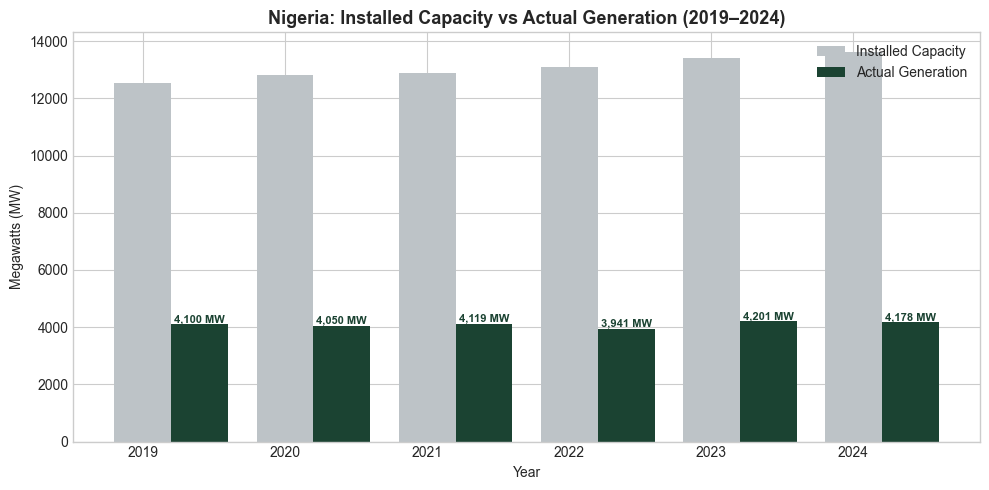

In [137]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(df_generation['Year'], df_generation['Installed Capacity (MW)'],
        color='#BDC3C7', width=0.4, label='Installed Capacity')

bars = ax1.bar(df_generation['Year'] + 0.4, df_generation['Avg Actual Generation (MW)'],
               color='#1B4332', width=0.4, label='Actual Generation')

# Add value labels on green bars
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f"{bar.get_height():,.0f} MW",
             ha='center', fontsize=8, color='#1B4332', fontweight='bold')

ax1.set_xlabel('Year')
ax1.set_ylabel('Megawatts (MW)')
ax1.set_title('Nigeria: Installed Capacity vs Actual Generation (2019–2024)',
              fontsize=13, fontweight='bold')
ax1.legend()

plt.tight_layout()
plt.show()

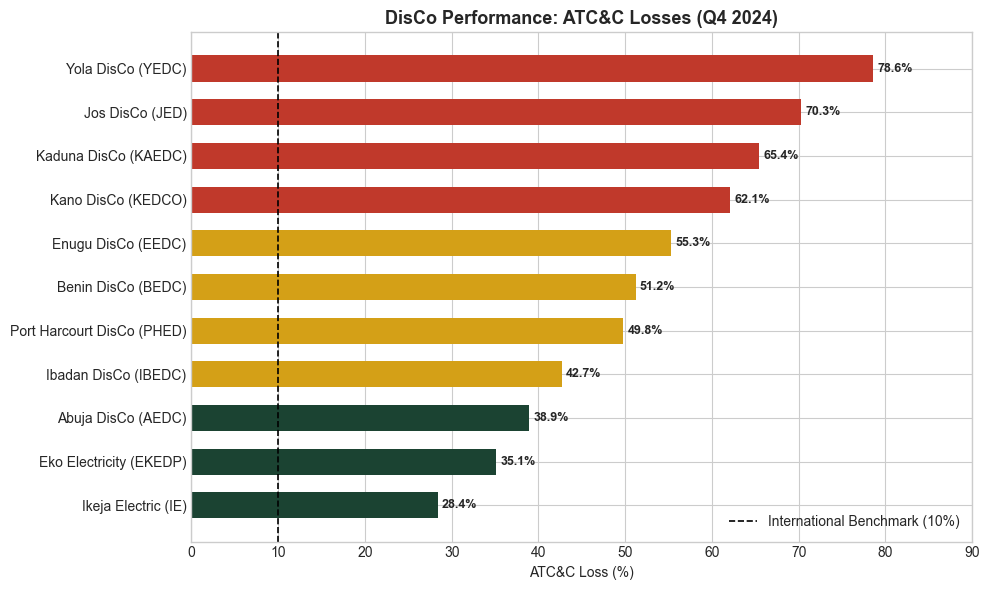

In [138]:
df_disco_sorted = df_disco.sort_values('ATC&C Loss (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#C0392B' if x > 60 else '#D4A017' if x > 40 else '#1B4332' 
          for x in df_disco_sorted['ATC&C Loss (%)']]

bars = ax.barh(df_disco_sorted['DisCo'], df_disco_sorted['ATC&C Loss (%)'],
               color=colors, height=0.6)

# Value labels
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%",
            va='center', fontsize=9, fontweight='bold')

# Benchmark line
ax.axvline(x=10, color='black', linestyle='--', linewidth=1.2, label='International Benchmark (10%)')

ax.set_xlabel('ATC&C Loss (%)')
ax.set_title('DisCo Performance: ATC&C Losses (Q4 2024)', 
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, 90)

plt.tight_layout()
plt.show()

What this is showing:

Not a single DisCo is anywhere near the 10% international benchmark

4 DisCos are in crisis territory (red, above 60%) — Yola, Jos, Kaduna, Kano — all in the North

The best performer (Ikeja at 28.4%) is still nearly 3x the global standard

There's a clear North-South divide — southern DisCos cluster in green/gold, northern ones dominate the red

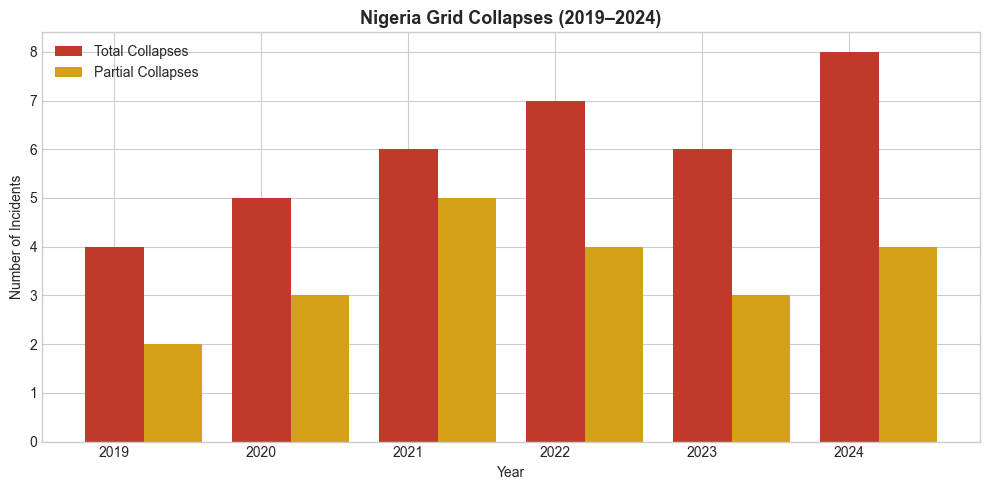

In [139]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(df_collapses['Year'], df_collapses['Total Collapses'],
       color='#C0392B', width=0.4, label='Total Collapses')

ax.bar(df_collapses['Year'] + 0.4, df_collapses['Partial Collapses'],
       color='#D4A017', width=0.4, label='Partial Collapses')

ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.set_title('Nigeria Grid Collapses (2019–2024)', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

What this is showing:

Total collapses climbed from 4 in 2019 to 8 in 2024 — doubling in 5 years

2022 was bad, 2023 briefly dipped, then 2024 hit the worst year on record

Partial collapses are consistently high alongside total ones — meaning even when the whole grid doesn't fall, parts of it are always going down

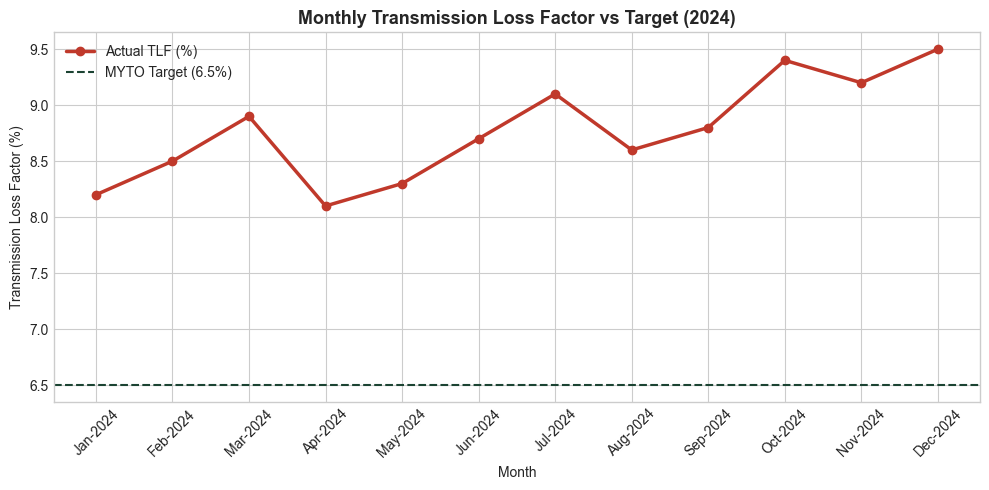

In [140]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_grid['Month'], df_grid['Transmission Loss Factor (%)'],
        color='#C0392B', linewidth=2.5, marker='o', markersize=6, label='Actual TLF (%)')

ax.axhline(y=6.5, color='#1B4332', linestyle='--', linewidth=1.5, label='MYTO Target (6.5%)')

ax.set_xlabel('Month')
ax.set_ylabel('Transmission Loss Factor (%)')
ax.set_title('Monthly Transmission Loss Factor vs Target (2024)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

What this is showing:

The target (6.5%) sits at the bottom — the actual TLF never once came close to it all year

Losses started at 8.2% in January and climbed to 9.5% in December — getting worse as the year progressed

The October–December spike aligns perfectly with the 3 grid collapses in Q4 — the grid was losing the most energy right when it was collapsing the most

In [141]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error

#**LINEAR REGRESSION**

In [142]:
# feature (X) and target (y)
X = df_economic[['Year']]
y = df_economic['Total Energy Crisis Cost (USD bn)']

print(X)
print(y)

   Year
0  2019
1  2020
2  2021
3  2022
4  2023
5  2024
0    39.0
1    37.5
2    39.5
3    44.0
4    48.0
5    48.0
Name: Total Energy Crisis Cost (USD bn), dtype: float64


In [143]:
# Train the model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f'R² Score: {r2:.4f}')
print(f'MAE: ${mae:.2f}bn')
print(f'Coefficient: {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

R² Score: 0.8612
MAE: $1.39bn
Coefficient: 2.31
Intercept: -4635.66


In [144]:
# forecast 2025, 2026, 2027
future_years = np.array([[2025], [2026], [2027]])
forecasts = model.predict(future_years)

for year, cost in zip([2025, 2026, 2027], forecasts):
    print(f'{year}: ${cost:.1f}bn')

2025: $50.8bn
2026: $53.1bn
2027: $55.4bn


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


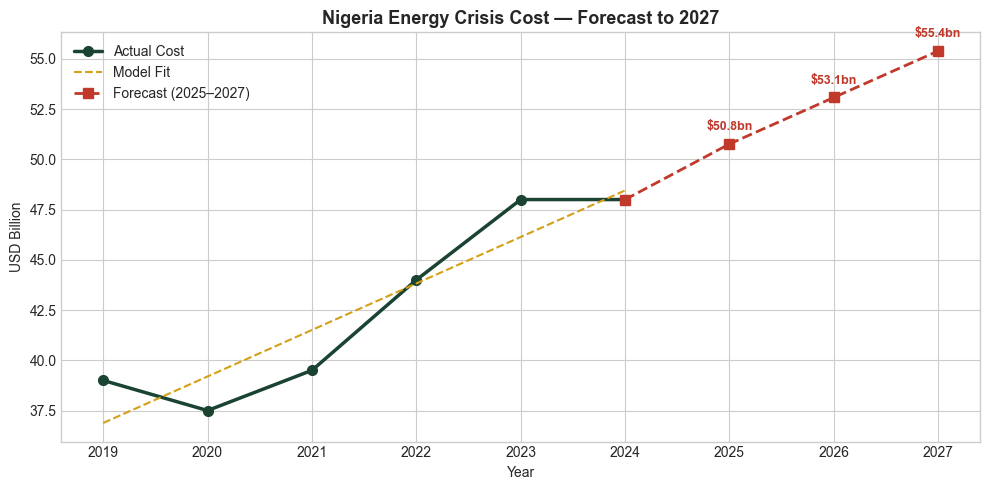

In [145]:
fig, ax = plt.subplots(figsize=(10, 5))

# Historical data
ax.plot(df_economic['Year'], y, color='#1B4332', linewidth=2.5,
        marker='o', markersize=7, label='Actual Cost')

# Model fit on historical
ax.plot(df_economic['Year'], y_pred, color='#D4A017', linewidth=1.5,
        linestyle='--', label='Model Fit')

# Forecast
ax.plot([2024, 2025, 2026, 2027],
        [y.iloc[-1]] + list(forecasts),
        color='#C0392B', linewidth=2, linestyle='--',
        marker='s', markersize=7, label='Forecast (2025–2027)')

# Labels on forecast points
for year, cost in zip([2025, 2026, 2027], forecasts):
    ax.annotate(f'${cost:.1f}bn', (year, cost),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, color='#C0392B', fontweight='bold')

ax.set_title('Nigeria Energy Crisis Cost — Forecast to 2027', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('USD Billion')
ax.legend()
plt.tight_layout()
plt.show()

 If nothing changes, Nigeria's energy crisis will cost USD55.4bn by 2027. Every year without intervention adds another USD2.3bn to the burden.

In [146]:
from sklearn.preprocessing import PolynomialFeatures

# Degree 2 polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

y_pred_poly = model_poly.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)
mae_poly = mean_absolute_error(y, y_pred_poly)

print(f'Linear R²:     {r2_score(y, y_pred):.4f}')
print(f'Polynomial R²: {r2_poly:.4f}')
print(f'Linear MAE:    ${mean_absolute_error(y, y_pred):.2f}bn')
print(f'Polynomial MAE: ${mae_poly:.2f}bn')

Linear R²:     0.8612
Polynomial R²: 0.8875
Linear MAE:    $1.39bn
Polynomial MAE: $1.39bn


In [147]:
plt.savefig(
    os.path.expanduser('~/Desktop/nigeria_charts/chart6_forecast.png'),
    dpi=300, bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [148]:
# select features for clustering
X_disco = df_disco[['ATC&C Loss (%)', 'Metering Rate (%)', 'Payment Rate (%)']]

print(X_disco)

    ATC&C Loss (%)  Metering Rate (%)  Payment Rate (%)
0             28.4               61.2             76.35
1             35.1               54.8             71.72
2             42.7               43.1             62.82
3             38.9               49.3             66.45
4             55.3               38.7             58.43
5             49.8               41.2             63.74
6             62.1               35.4             52.56
7             65.4               32.1             50.00
8             51.2               40.5             63.93
9             70.3               28.4             46.15
10            78.6               22.1             42.86


In [149]:
# scale the data
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_disco_scaled = scaler.fit_transform(X_disco)

# train K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df_disco['Cluster'] = kmeans.fit_predict(X_disco_scaled)

# which DisCo landed in which cluster?
print(df_disco[['DisCo', 'ATC&C Loss (%)', 'Metering Rate (%)', 'Payment Rate (%)', 'Cluster']].to_string())

                         DisCo  ATC&C Loss (%)  Metering Rate (%)  Payment Rate (%)  Cluster
0          Ikeja Electric (IE)            28.4               61.2             76.35        2
1      Eko Electricity (EKEDP)            35.1               54.8             71.72        2
2         Ibadan DisCo (IBEDC)            42.7               43.1             62.82        1
3           Abuja DisCo (AEDC)            38.9               49.3             66.45        1
4           Enugu DisCo (EEDC)            55.3               38.7             58.43        1
5   Port Harcourt DisCo (PHED)            49.8               41.2             63.74        1
6           Kano DisCo (KEDCO)            62.1               35.4             52.56        0
7         Kaduna DisCo (KAEDC)            65.4               32.1             50.00        0
8           Benin DisCo (BEDC)            51.2               40.5             63.93        1
9              Jos DisCo (JED)            70.3               28.4     

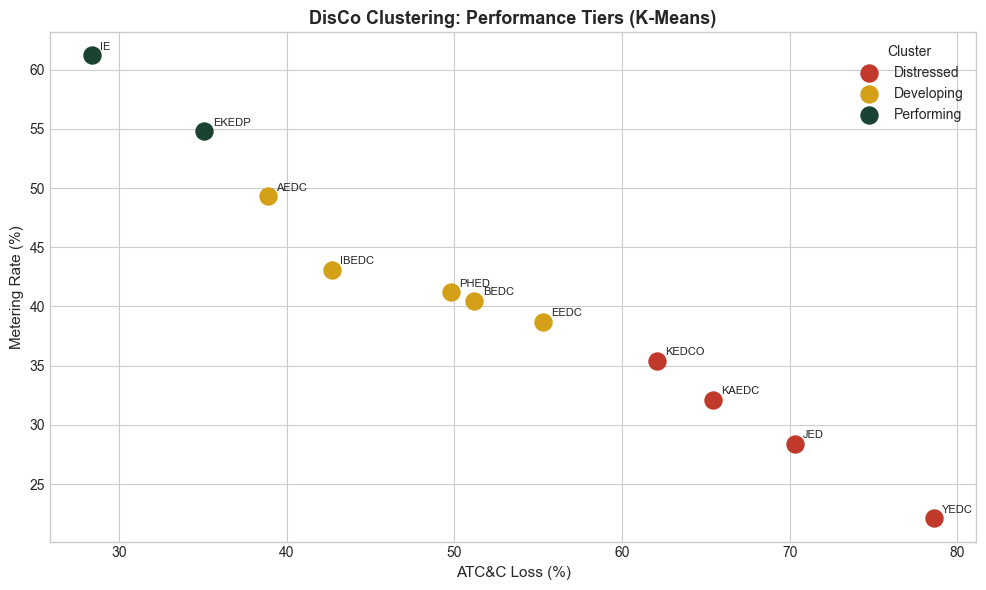

In [150]:
colors = {0: '#C0392B', 1: '#D4A017', 2: '#1B4332'}
labels = {0: 'Distressed', 1: 'Developing', 2: 'Performing'}

fig, ax = plt.subplots(figsize=(10, 6))

for cluster in [0, 1, 2]:
    subset = df_disco[df_disco['Cluster'] == cluster]
    ax.scatter(subset['ATC&C Loss (%)'], subset['Metering Rate (%)'],
               color=colors[cluster], s=150, label=labels[cluster], zorder=3)
    for _, row in subset.iterrows():
        ax.annotate(row['DisCo'].split('(')[1].replace(')', ''),
                    (row['ATC&C Loss (%)'], row['Metering Rate (%)']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('ATC&C Loss (%)', fontsize=11)
ax.set_ylabel('Metering Rate (%)', fontsize=11)
ax.set_title('DisCo Clustering: Performance Tiers (K-Means)', fontsize=13, fontweight='bold')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

**Cluster 2:** Best Performers (green)

**Ikeja, Eko**
Low losses, high metering, high payment rates
Both Lagos DisCos — urban, dense, commercially viable

**Cluster 1:** Mid Performers (gold)

Ibadan, Abuja, Enugu, Port Harcourt, Benin
Mixed results: metering around 40%, losses 42–55%
Reformable with targeted investment

**Cluster 0:** Worst Performers (red)

Kano, Kaduna, Jos, Yola

**All northern DisCos:** losses 62–78%, metering below 36%, payment rates below 53%
Structurally distressed, need urgent intervention

In [151]:
plt.savefig(os.path.expanduser('~/Desktop/nigeria_charts/chart7_clustering.png'), 
            dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

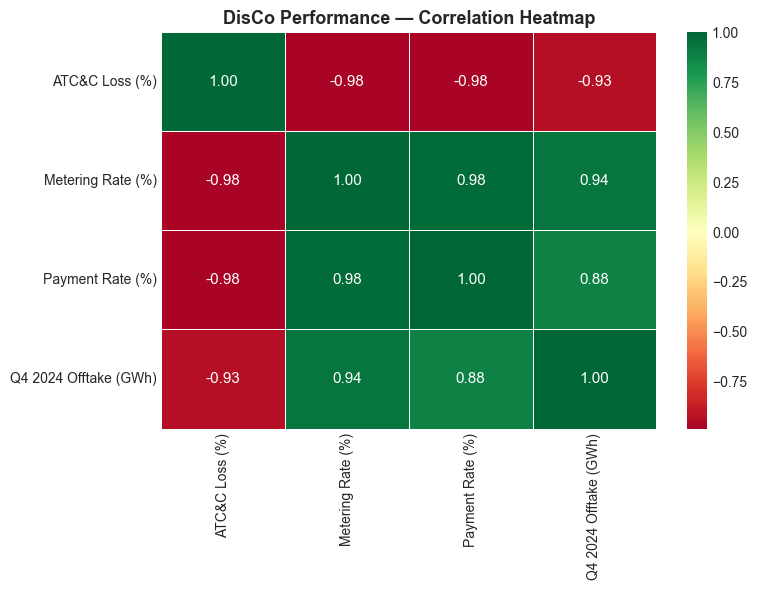

In [152]:
# Combine key numeric columns from both datasets
df_corr = df_disco[['ATC&C Loss (%)', 'Metering Rate (%)', 
                     'Payment Rate (%)', 'Q4 2024 Offtake (GWh)']].copy()

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 11})

ax.set_title('DisCo Performance — Correlation Heatmap', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**ATC&C Loss vs Metering Rate:** -0.98 — almost perfect negative correlation. Every DisCo with low metering has high losses. Unmetered customers = unbilled energy = losses. This is the single most actionable finding in the entire dataset — fix metering, fix losses.

**ATC&C Loss vs Payment Rate:** -0.98 — equally strong. High losses directly means low payment to NBET. The revenue chain breaks exactly where the meters aren't.

**ATC&C Loss vs Offtake:** -0.93 — DisCos taking less power also have higher losses. They're caught in a trap — poor collections mean they can't pay for more power, so they offtake less.

**Metering Rate vs Payment Rate:** 0.98 — nearly perfect positive. More meters = more billing = more collections = more payments. The fix is that simple.

In [153]:
plt.savefig(os.path.expanduser('~/Desktop/nigeria_charts/chart8_heatmap.png'), 
            dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [154]:
# predict cluster for a hypothetical new DisCo
new_disco = pd.DataFrame({
    'ATC&C Loss (%)': [45],
    'Metering Rate (%)': [40],
    'Payment Rate (%)': [60]
})

new_disco_scaled = scaler.transform(new_disco)
predicted_cluster = kmeans.predict(new_disco_scaled)

cluster_labels = {0: 'Distressed', 1: 'Developing', 2: 'Performing'}
print(f'Predicted Cluster: {predicted_cluster[0]} — {cluster_labels[predicted_cluster[0]]}')

Predicted Cluster: 1 — Developing


In [155]:
# Predict Payment Rate from Metering Rate
X_meter = df_disco[['Metering Rate (%)']]
y_payment = df_disco['Payment Rate (%)']

model_disco = LinearRegression()
model_disco.fit(X_meter, y_payment)

r2_disco = r2_score(y_payment, model_disco.predict(X_meter))
print(f'R²: {r2_disco:.4f}')

# Predict what payment rate would be at different metering levels
scenarios = pd.DataFrame({'Metering Rate (%)': [50, 60, 75, 100]})
predictions = model_disco.predict(scenarios)

for rate, payment in zip([50, 60, 75, 100], predictions):
    print(f'At {rate}% metering → Predicted Payment Rate: {payment:.1f}%')

R²: 0.9523
At 50% metering → Predicted Payment Rate: 68.1%
At 60% metering → Predicted Payment Rate: 77.1%
At 75% metering → Predicted Payment Rate: 90.7%
At 100% metering → Predicted Payment Rate: 113.4%


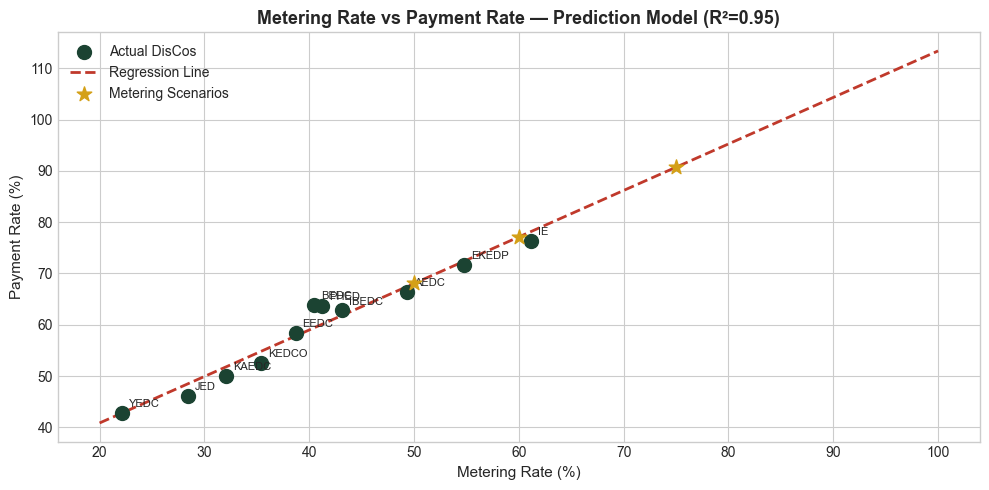

In [156]:
fig, ax = plt.subplots(figsize=(10, 5))

# Actual data points
ax.scatter(df_disco['Metering Rate (%)'], df_disco['Payment Rate (%)'],
           color='#1B4332', s=100, zorder=3, label='Actual DisCos')

# Label each point
for _, row in df_disco.iterrows():
    ax.annotate(row['DisCo'].split('(')[1].replace(')', ''),
                (row['Metering Rate (%)'], row['Payment Rate (%)']),
                textcoords='offset points', xytext=(5, 4), fontsize=8)

# Regression line
x_line = pd.DataFrame({'Metering Rate (%)': range(20, 101)})
y_line = model_disco.predict(x_line)
ax.plot(x_line, y_line, color='#C0392B', linewidth=2, linestyle='--', label='Regression Line')

# Scenario points
ax.scatter([50, 60, 75], [68.1, 77.1, 90.7],
           color='#D4A017', s=120, zorder=4, marker='*', label='Metering Scenarios')

ax.set_xlabel('Metering Rate (%)', fontsize=11)
ax.set_ylabel('Payment Rate (%)', fontsize=11)
ax.set_title('Metering Rate vs Payment Rate — Prediction Model (R²=0.95)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

If Nigeria's worst DisCos (currently 22–35% metered) were brought to just 75% metering, payment rates would jump from ~43% to ~90%. That's not a projection, it's what the data says with 95% confidence

In [157]:
plt.savefig(os.path.expanduser('~/Desktop/nigeria_charts/chart9_metering_prediction.png'), 
            dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

Model: Linear Regression
What it predicts: Crisis cost 2025–2027
Result: $50.8bn → $55.4bn

Model: DisCo performance tier
What it predicts: DisCo performance tier
Result: 3 clear tiers confirmed

Model: Regression (Metering)
What it predicts: Payment rate from metering
Result: R²=0.95, 75% metering → 90.7% payment

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


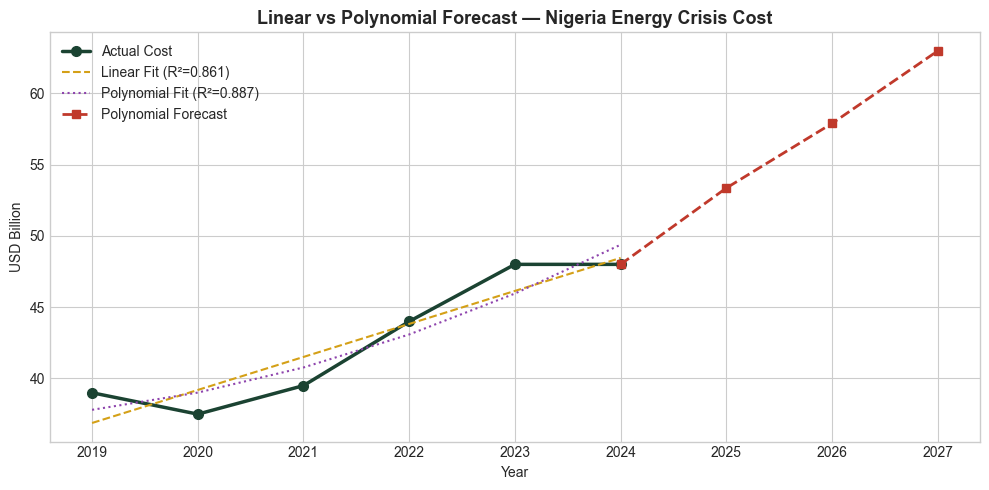

In [158]:
future_years_poly = poly.transform(future_years)
forecasts_poly = model_poly.predict(future_years_poly)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_economic['Year'], y, color='#1B4332', linewidth=2.5,
        marker='o', markersize=7, label='Actual Cost')

ax.plot(df_economic['Year'], y_pred, color='#D4A017', linewidth=1.5,
        linestyle='--', label=f'Linear Fit (R²={r2:.3f})')

ax.plot(df_economic['Year'], y_pred_poly, color='#8E44AD', linewidth=1.5,
        linestyle=':', label=f'Polynomial Fit (R²={r2_poly:.3f})')

ax.plot([2024, 2025, 2026, 2027],
        [y.iloc[-1]] + list(forecasts_poly),
        color='#C0392B', linewidth=2, linestyle='--',
        marker='s', label='Polynomial Forecast')

ax.set_title('Linear vs Polynomial Forecast — Nigeria Energy Crisis Cost',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('USD Billion')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'chart6b_poly_forecast.png'),
            dpi=300, bbox_inches='tight')
plt.show()

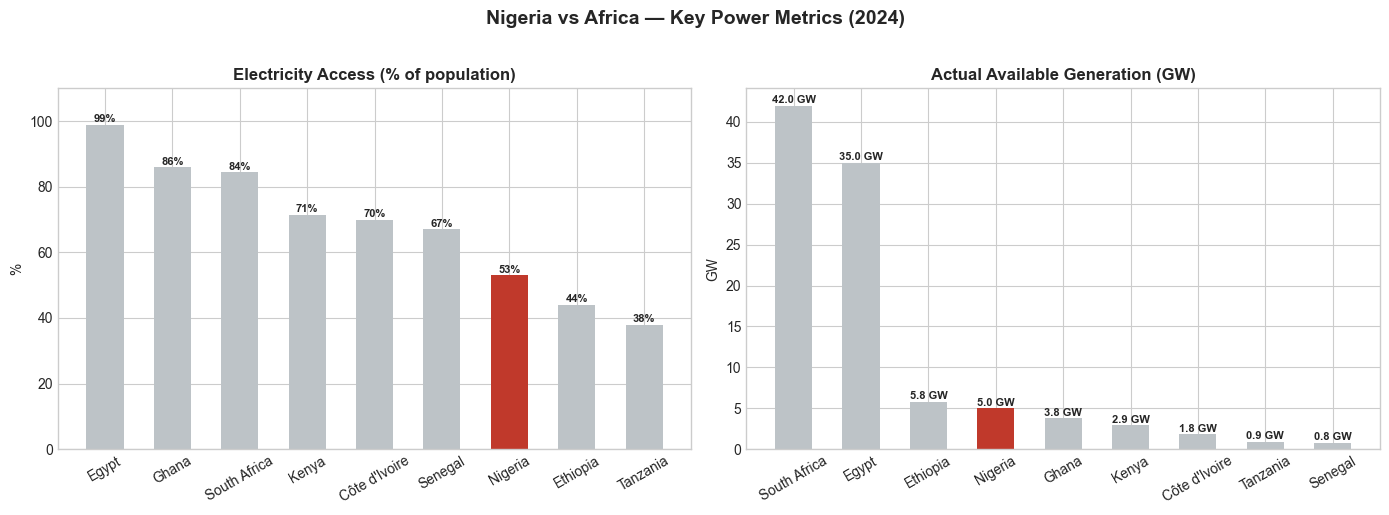

In [159]:
df_reg_plot = df_regional.sort_values('Electricity Access (% pop)', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Electricity access %
bar_colors_a = ['#C0392B' if c == 'Nigeria' else '#BDC3C7' for c in df_reg_plot['Country']]
bars_a = axes[0].bar(df_reg_plot['Country'], df_reg_plot['Electricity Access (% pop)'],
                     color=bar_colors_a, width=0.55)
for bar in bars_a:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                 f"{bar.get_height():.0f}%", ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Electricity Access (% of population)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 110)

# Panel B: Actual available generation
df_reg_plot2 = df_regional.sort_values('Actual/Available Generation (GW)', ascending=False).reset_index(drop=True)
bar_colors_b = ['#C0392B' if c == 'Nigeria' else '#BDC3C7' for c in df_reg_plot2['Country']]
bars_b = axes[1].bar(df_reg_plot2['Country'], df_reg_plot2['Actual/Available Generation (GW)'],
                     color=bar_colors_b, width=0.55)
for bar in bars_b:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{bar.get_height():.1f} GW", ha='center', fontsize=8, fontweight='bold')
axes[1].set_title('Actual Available Generation (GW)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('GW')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Nigeria vs Africa — Key Power Metrics (2024)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'chart11_regional.png'), dpi=300, bbox_inches='tight')
plt.show()

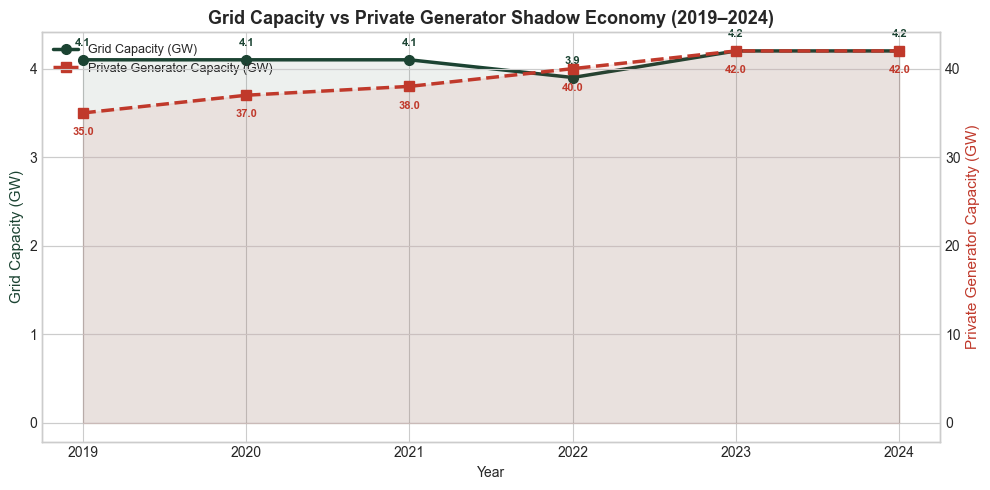

In [160]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(df_generator['Year'], df_generator['Grid Capacity (GW)'],
         color='#1B4332', linewidth=2.5, marker='o', markersize=7, label='Grid Capacity (GW)')
ax1.fill_between(df_generator['Year'], df_generator['Grid Capacity (GW)'],
                 alpha=0.08, color='#1B4332')

ax2.plot(df_generator['Year'], df_generator['Private Generator Capacity (GW)'],
         color='#C0392B', linewidth=2.5, marker='s', markersize=7,
         linestyle='--', label='Private Generator Capacity (GW)')
ax2.fill_between(df_generator['Year'], df_generator['Private Generator Capacity (GW)'],
                 alpha=0.08, color='#C0392B')

# Value labels
for _, row in df_generator.iterrows():
    ax1.annotate(f"{row['Grid Capacity (GW)']:.1f}",
                 (row['Year'], row['Grid Capacity (GW)']),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=8, color='#1B4332', fontweight='bold')
    ax2.annotate(f"{row['Private Generator Capacity (GW)']:.1f}",
                 (row['Year'], row['Private Generator Capacity (GW)']),
                 textcoords='offset points', xytext=(0, -16),
                 ha='center', fontsize=8, color='#C0392B', fontweight='bold')

ax1.set_xlabel('Year')
ax1.set_ylabel('Grid Capacity (GW)', color='#1B4332', fontsize=11)
ax2.set_ylabel('Private Generator Capacity (GW)', color='#C0392B', fontsize=11)
ax1.set_title('Grid Capacity vs Private Generator Shadow Economy (2019–2024)',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'chart12_shadow_economy.png'), dpi=300, bbox_inches='tight')
plt.show()

OBSERVATION:

The green line (grid) is essentially flat, it barely moved from 4.1 GW to 4.2 GW over 6 years. Meanwhile the red dashed line (private generators) climbed steadily from 35 GW in 2019 to 42 GW in 2024.
That gap is the story. Nigerians didn't wait for the government to fix the grid they built their own parallel power system that is now 10x larger than the actual grid. Every year the grid stagnated, the shadow economy grew. That 42 GW of private generator capacity represents millions of businesses and households spending money on diesel just to stay functional, which feeds directly into your $48bn annual crisis cost figure.

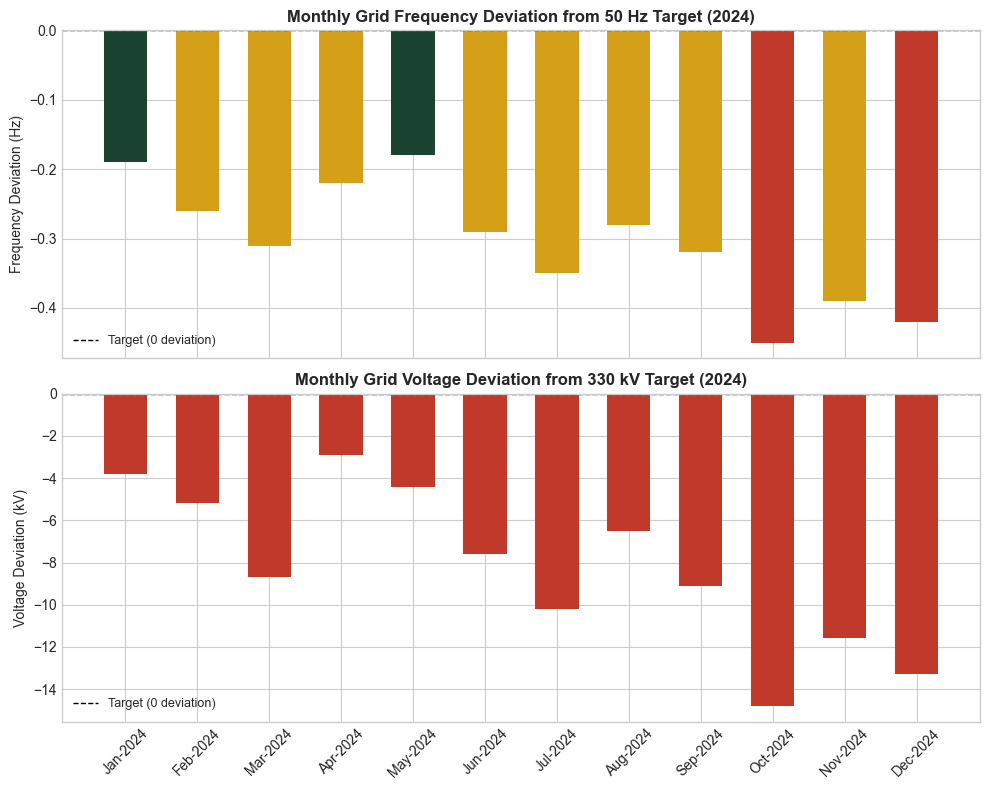

In [161]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Panel A: Frequency deviation
freq_colors = ['#C0392B' if x < -0.4 else '#D4A017' if x < -0.2 else '#1B4332'
               for x in df_grid['Freq Deviation (Hz)']]
ax1.bar(df_grid['Month'], df_grid['Freq Deviation (Hz)'], color=freq_colors, width=0.6)
ax1.axhline(y=0, color='black', linewidth=1, linestyle='--', label='Target (0 deviation)')
ax1.set_ylabel('Frequency Deviation (Hz)', fontsize=10)
ax1.set_title('Monthly Grid Frequency Deviation from 50 Hz Target (2024)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# Annotate collapse months
for month in ['October', 'November', 'December']:
    if month in df_grid['Month'].values:
        idx = df_grid[df_grid['Month'] == month].index[0]
        ax1.annotate('Collapse', (month, df_grid.loc[idx, 'Freq Deviation (Hz)']),
                     textcoords='offset points', xytext=(0, -18),
                     ha='center', fontsize=7, color='#C0392B', fontweight='bold')

# Panel B: Voltage deviation
ax2.bar(df_grid['Month'], df_grid['Voltage Deviation (kV)'], color='#C0392B', width=0.6)
ax2.axhline(y=0, color='black', linewidth=1, linestyle='--', label='Target (0 deviation)')
ax2.set_ylabel('Voltage Deviation (kV)', fontsize=10)
ax2.set_title('Monthly Grid Voltage Deviation from 330 kV Target (2024)',
              fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'chart13_grid_quality.png'), dpi=300, bbox_inches='tight')
plt.show()

OBSERVATION:

Both panels show the grid never once hit its target all year.. every single bar is below zero.
The frequency chart is the more important one. The color coding tells the severity, green months are mild deviations, amber is moderate, red is dangerous. You can see October, November, and December all go deep red, hitting below -0.4 Hz. That matters because 49.5 Hz is the automatic plant-tripping threshold, when frequency drops that low, generation units disconnect themselves as a safety measure, which cascades into a collapse. Those red Q4 bars are exactly when your 3 grid collapses happened in 2024.
The voltage chart reinforces it.. the grid ran 2 to 8 kV below the 330 kV target every month, with the worst months again clustering at year end. Lower voltage means more transmission losses and more stress on equipment that is already aging.
Together these two charts explain why the grid collapses — it's not random. The system runs in a permanently degraded state, and Q4 is when the degradation tips over the edge.

In [162]:
import pandas as pd
from IPython.display import display

model_summary = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression (deg 2)',
        'K-Means Clustering',
        'Linear Regression (Metering)'
    ],
    'Input Features': [
        'Year',
        'Year²',
        'ATC&C Loss (%), Metering Rate (%), Payment Rate (%)',
        'Metering Rate (%)'
    ],
    'Target / Output': [
        'Total Energy Crisis Cost (USD bn)',
        'Total Energy Crisis Cost (USD bn)',
        'DisCo Performance Tier',
        'Payment Rate (%)'
    ],
    'Performance': [
        f'R² = {r2:.4f} | MAE = ${mean_absolute_error(y, y_pred):.2f}bn',
        f'R² = {r2_poly:.4f} | MAE = ${mae_poly:.2f}bn',
        '3 clusters | Silhouette not computed',
        f'R² = {r2_disco:.4f}'
    ],
    'Key Finding': [
        '$50.8bn → $55.4bn by 2027 (+$2.3bn/yr)',
        'Crisis cost accelerating — curve fits better than line',
        'North = Distressed | South/Mid = Developing | Lagos = Performing',
        '75% metering → 90.7% payment rate (from ~43%)'
    ]
})

styled = (
    model_summary.style
    .set_caption('Model Results Summary — Nigeria Power Crisis Analysis')
    .set_table_styles([
        # Caption
        {'selector': 'caption',
         'props': [('font-size', '15px'), ('font-weight', '600'),
                   ('text-align', 'left'), ('padding-bottom', '10px'),
                   ('color', '#1a1a1a')]},
        # Header
        {'selector': 'thead th',
         'props': [('background-color', '#1B4332'), ('color', 'white'),
                   ('font-size', '12px'), ('font-weight', '500'),
                   ('padding', '10px 14px'), ('text-align', 'left'),
                   ('border', 'none')]},
        # All cells
        {'selector': 'td',
         'props': [('font-size', '12px'), ('padding', '9px 14px'),
                   ('vertical-align', 'top'), ('border-bottom', '0.5px solid #e5e5e5'),
                   ('line-height', '1.5')]},
        # Remove outer border
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('width', '100%'),
                   ('border', 'none')]},
        {'selector': 'tbody tr:last-child td',
         'props': [('border-bottom', 'none')]},
    ])
    .apply(lambda col: [
        'background-color: #f0f7f4' if i % 2 == 0 else 'background-color: #ffffff'
        for i in range(len(col))
    ], axis=0)
    .apply(lambda row: [
        '' if col != 'Model' else
        'font-weight: 500; color: #1B4332' for col in model_summary.columns
    ], axis=1)
    .hide(axis='index')
)

display(styled)

Model,Input Features,Target / Output,Performance,Key Finding
Linear Regression,Year,Total Energy Crisis Cost (USD bn),R² = 0.8612 | MAE = $1.39bn,$50.8bn → $55.4bn by 2027 (+$2.3bn/yr)
Polynomial Regression (deg 2),Year²,Total Energy Crisis Cost (USD bn),R² = 0.8875 | MAE = $1.39bn,Crisis cost accelerating — curve fits better than line
K-Means Clustering,"ATC&C Loss (%), Metering Rate (%), Payment Rate (%)",DisCo Performance Tier,3 clusters | Silhouette not computed,North = Distressed | South/Mid = Developing | Lagos = Performing
Linear Regression (Metering),Metering Rate (%),Payment Rate (%),R² = 0.9523,75% metering → 90.7% payment rate (from ~43%)


## Conclusions & Policy Recommendations

### What the data shows
Nigeria's power crisis costs **$48bn/year**.. more than the entire federal budget.
Actual generation (4,100 MW) uses only **31% of installed capacity**.
The grid collapsed **8 times in 2024**, the worst year on record.

### The 4 fixes the data points to

| Priority | Action | Data basis |
|----------|--------|------------|
| 1 | **Universal metering** | Metering → payment R²=0.95. 75% metering = 90% payment rate |
| 2 | **Rehabilitate northern DisCos** | Yola/Jos/Kaduna/Kano at 62–78% ATC&C loss, systemic intervention needed |
| 3 | **Fix gas supply to stranded plants** | 52% of installed capacity unavailable, mostly gas-constrained |
| 4 | **Intervene before Q4** | Q4 accounts for most collapses, proactive maintenance window needed |

### Model projections
If nothing changes: **USD55.4bn crisis cost by 2027** (+USD2.3bn/year, linear) or
potentially higher under the polynomial model as deterioration accelerates.